# Daily heat: counts, runs and nighttime exposure

**Climate & Health · Lesson 03 · 20–35 minutes**

[Run this lesson in Python Lab](https://jltobias.github.io/JupyterLite-Climate-and-Health/lite/lab/index.html?path=notebooks/03_daily_heat.ipynb)

Calculate daily extremes with correct definitions: TXx=max(Tmax), TNn=min(Tmin), TXn=min(Tmax), TNx=max(Tmin). Count days above a chosen threshold separately from the longest consecutive run. A temperature threshold is not a mortality threshold.

**Learning goal:** Run the analysis, explain its units and assumptions, then adapt the exercise.

Data labels: **observed NASA** appears in lesson 01. Fictional facility scenarios, local temperatures, costs, flows and modeled impacts are **synthetic teaching data**. The separate **archived Healthsites / OpenStreetMap points** are actual public map records with unverified current services; no synthetic impacts or funding claims apply to them.

In [1]:
from pathlib import Path
import sys, json, statistics
root = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / "healthlab.py").exists()), None)
if root is None:
    raise RuntimeError("Open this notebook inside the bundled content folder; healthlab.py and data/ are required.")
if str(root) not in sys.path: sys.path.insert(0, str(root))
import healthlab as h
from IPython.display import display, SVG
cases = h.cases()
print("Loaded", len(cases), "fictional facility scenarios; city coordinates are context only.")

Loaded 7 fictional facility scenarios; city coordinates are context only.


## Analysis 1

Run this cell, then inspect the units and result before continuing.

{'TXx': 38.75, 'TNn': 19.85, 'TXn': 28.21, 'TNx': 31.19, 'days_above': 133, 'longest_run': 82}


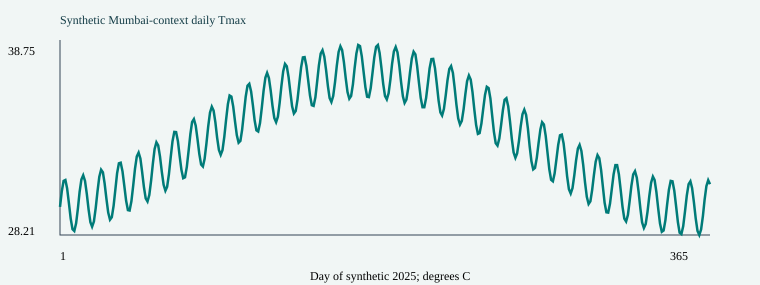

In [2]:
daily = [r for r in h.read_csv("daily-heat.csv") if r["case_id"] == "mumbai"]
tmax, tmin = [float(r["tmax_c"]) for r in daily], [float(r["tmin_c"]) for r in daily]
print(h.heat_indices(tmax,tmin,threshold=35))
display(SVG(h.line_svg(list(range(1,366)), tmax, "Synthetic Mumbai-context daily Tmax", "Day of synthetic 2025; degrees C")))

## Analysis 2

Run this cell, then inspect the units and result before continuing.

In [3]:
a, b = [36,36,34,34,36,36], [36,36,36,36,34,34]
print("Same hot-day count:", sum(x>35 for x in a), sum(x>35 for x in b))
print("Different longest runs:", h.longest_run(a,35), h.longest_run(b,35))
print("Season-year keys:", h.season_key("2024-12-15"), h.season_key("2025-01-15"))
assert h.season_key("2024-12-15") == h.season_key("2025-01-15")

Same hot-day count: 4 4
Different longest runs: 2 4
Season-year keys: (2025, 'DJF') (2025, 'DJF')


## Interpretation

The same number of hot days can occur as isolated days or persistent runs. Humidity, work intensity, housing, acclimatization and health conditions affect exposure; none is captured by these invented daily temperatures.

## Your exercise

Calculate results at 34 and 36 °C. Repeat for Durban. Compare nighttime minima and daytime maxima. Explain why monthly hot-day counts alone cannot reconstruct a daily sequence. Use DJF/MAM/JJA/SON rather than globally labeling DJF winter.

## Worked reasoning check

Before trusting a changed result, identify the input you changed, predict the direction, and compare with the printed baseline. Explain any threshold or missing-data behavior; a valid calculation alone does not validate a real-world claim.

## Source and limitation

WHO heat and health: https://www.who.int/news-room/fact-sheets/detail/climate-change-heat-and-health . Original NB01/NB02/NB02B activities adapted with deterministic daily data; no observed local heat claims.

Original educational text: CC BY 4.0, James L. Tobias and contributors. Original synthetic fixtures: CC0. Original calculation code: MIT.